# 🚖 NYC Taxi Anomalous Trip Detection

## Use Case 5: Identify Anomalous Trips

### Notebook 2: Exploratory Data Analysis & Feature Engineering

### Objective

After validating the raw taxi data in Notebook 1, the next step is to understand trip behavior and engineer features that can help identify anomalous trips.

This notebook focuses on:

1. Missing value investigation
2. Exploratory Data Analysis (EDA)
3. Feature engineering
4. Feature selection for anomaly detection
5. Creation of a model-ready dataset

### Why Is This Important?

Isolation Forest does not understand business concepts such as:

- Unusually high speed
- Suspicious fare values
- Rare routes
- Unusual revenue patterns

These behaviors must first be converted into numerical features that the model can learn from.

# Step 1: Load Validated Dataset

Load the validated dataset produced in Notebook 1.

This dataset contains:

- Valid timestamps
- No impossible negative values
- Original taxi trip information

Potential anomalies have been preserved.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

df = pd.read_parquet(
    "/home/ed/Desktop/NYC_Taxi_Demand_Forecasting/USECASE5_Anomaly Detection/data/validate_taxi_data.parquet"
)

print(df.shape)

df.head()

(3560826, 11)


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,fare_amount,tip_amount,total_amount,PULocationID,DOLocationID,payment_type,RatecodeID
0,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,7.2,3.66,15.86,239,238,1,1.0
1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,7.9,0.00,13.65,163,162,2,1.0
2,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,10.7,2.50,18.95,43,237,1,1.0
3,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,38.7,11.11,55.56,142,209,1,1.0
4,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,13.5,3.85,23.10,88,144,1,1.0


# Step 2: Missing Value Investigation

Before handling missing values, we must understand:

- Which columns contain missing values?
- How many records are affected?
- Whether the feature is useful for anomaly detection?

Features will not be imputed blindly.

In [2]:
missing_df = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing Percentage":
        round(df.isna().mean()*100,2)
})

missing_df.sort_values(
    "Missing Percentage",
    ascending=False
)

,Missing Count,Missing Percentage
passenger_count,994749,27.94
RatecodeID,994749,27.94
tpep_pickup_datetime,0,0.00
tpep_dropoff_datetime,0,0.00
trip_distance,0,0.00
tip_amount,0,0.00
fare_amount,0,0.00
total_amount,0,0.00
PULocationID,0,0.00
DOLocationID,0,0.00


# Missing Value Strategy

After reviewing missing values and business relevance:

### Keep

- passenger_count
- RatecodeID

### Drop

- Airport_fee
- congestion_surcharge
- store_and_fwd_flag

Reason:

These columns provide limited value for trip anomaly detection and contain substantial missing values.

The retained columns contain potentially useful behavioral information.

In [3]:
columns_to_drop = [
    "Airport_fee",
    "congestion_surcharge",
    "store_and_fwd_flag"
]

existing_cols = [
    col for col in columns_to_drop
    if col in df.columns
]

df = df.drop(columns=existing_cols)

print(df.shape)

(3560826, 11)


# Step 3: Handle Missing Values

Isolation Forest cannot train on missing values.

Missing values are handled carefully:

### passenger_count

A missing indicator is created because missingness itself may contain information.

### RatecodeID

Missing values are assigned a separate category.

In [4]:
df["passenger_missing"] = (
    df["passenger_count"]
    .isna()
    .astype(int)
)

df["passenger_count"] = (
    df["passenger_count"]
    .fillna(
        df["passenger_count"].median()
    )
)



In [5]:
df["RatecodeID"] = (
    df["RatecodeID"]
    .fillna(0)
)

# Step 4: Trip Distance Analysis

Trip distance is one of the most important indicators of taxi behavior.

We analyze its distribution to understand:

- Typical trip lengths
- Long-distance trips
- Potential outlier regions

Outliers are NOT removed.

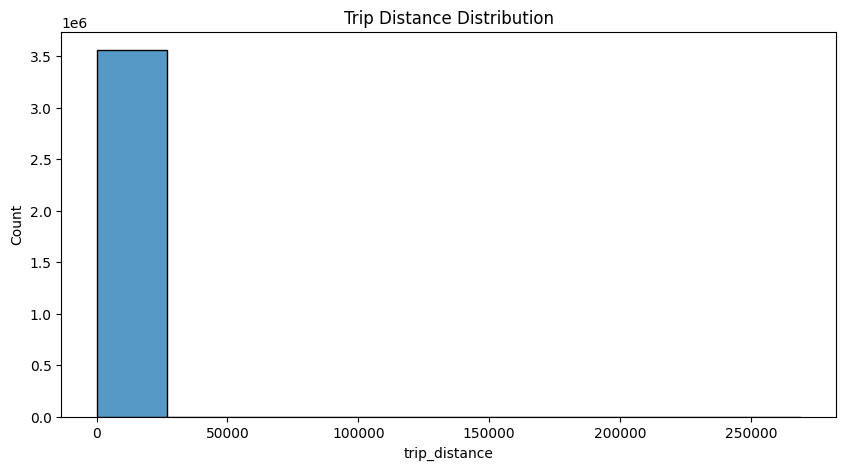

In [10]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["trip_distance"],
    bins=10
)

plt.title("Trip Distance Distribution")
plt.show()

# Step 5: Create Trip Duration

Trip duration is calculated using pickup and dropoff timestamps.

Duration is a core feature because many anomalies involve unusual travel times.

In [11]:
df["trip_duration"] = (
    df["tpep_dropoff_datetime"]
    -
    df["tpep_pickup_datetime"]
).dt.total_seconds() / 60

In [12]:
df["trip_duration"].describe()

count    3.560826e+06
mean     1.725409e+01
std      2.422654e+01
min     -1.170000e+01
25%      8.133333e+00
50%      1.338333e+01
75%      2.120000e+01
max      5.293333e+03
Name: trip_duration, dtype: float64

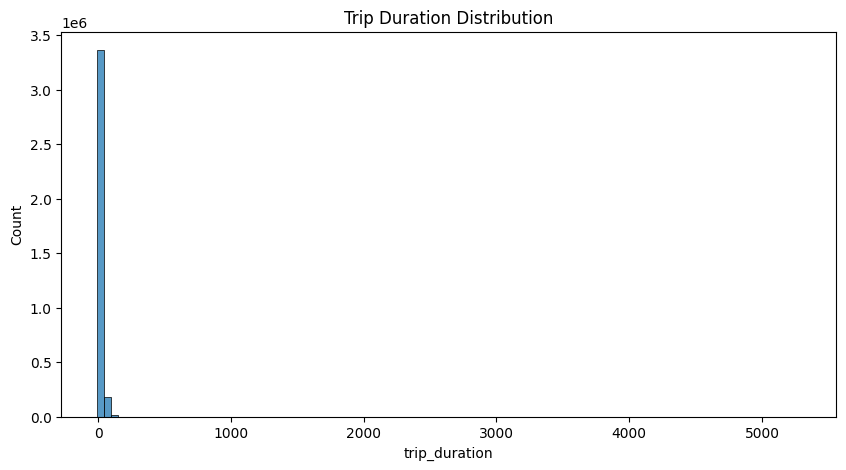

In [18]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["trip_duration"],
    bins=100
)

plt.title("Trip Duration Distribution")
plt.show()

# Step 6: Create Average Speed

Speed is one of the strongest anomaly indicators.

Example:

Distance = 50 miles

Duration = 5 minutes

Speed = 600 mph

Such trips may indicate data quality issues or operational irregularities.

In [19]:
df["speed"] = (
    df["trip_distance"]
    /
    (df["trip_duration"] / 60)
)

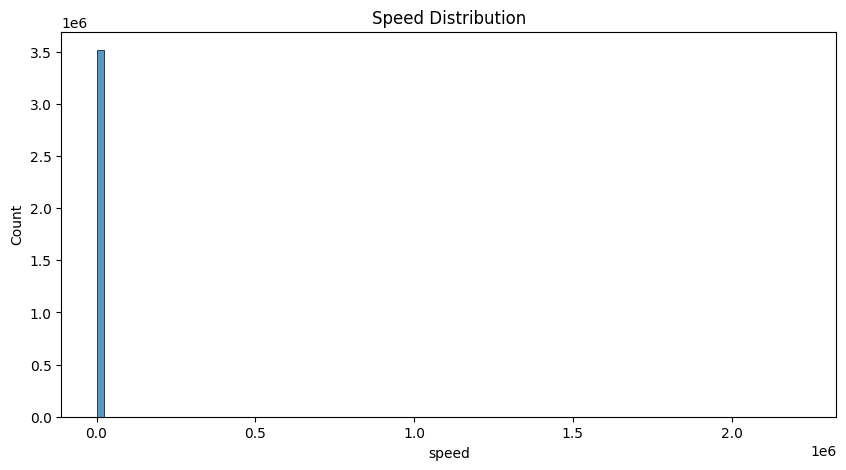

In [20]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["speed"],
    bins=100
)

plt.title("Speed Distribution")
plt.show()

# Step 7: Create Fare Per Mile

Fare per mile helps identify unusual pricing behavior.

Examples:

- Very low fare
- Extremely expensive trip
- Metering inconsistencies

In [21]:
df["fare_per_mile"] = (
    df["fare_amount"]
    /
    (df["trip_distance"] + 0.001)
)

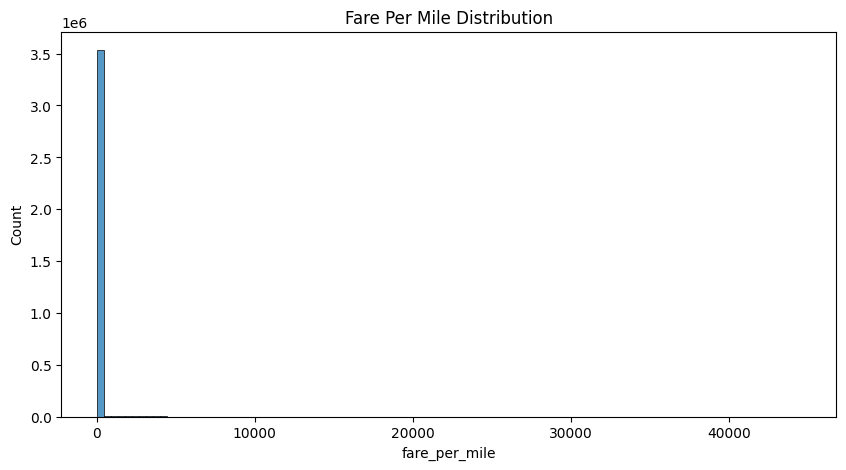

In [22]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["fare_per_mile"],
    bins=100
)

plt.title("Fare Per Mile Distribution")
plt.show()

# Step 8: Create Tip Percentage

Tip percentage measures customer tipping behavior.

Extremely unusual values may indicate anomalous transactions.

In [23]:
df["tip_percentage"] = (
    df["tip_amount"]
    /
    (df["fare_amount"] + 0.001)
) * 100

# Step 9: Create Revenue Per Minute

Revenue per minute measures trip profitability.

Unusual values may indicate suspicious trip records.

In [24]:
df["revenue_per_minute"] = (
    df["total_amount"]
    /
    (df["trip_duration"] + 0.001)
)

# Step 10: Create Route Frequency

Certain pickup-dropoff combinations occur frequently.

Rare routes may represent unusual travel behavior.

This feature captures route popularity.

In [25]:
df["route"] = (
    df["PULocationID"].astype(str)
    +
    "_"
    +
    df["DOLocationID"].astype(str)
)

route_freq = (
    df["route"]
    .value_counts()
)

df["route_frequency"] = (
    df["route"]
    .map(route_freq)
)

# Step 11: Create Time-Based Features

Taxi behavior varies significantly by:

- Hour of day
- Day of week

These features help capture temporal patterns.

In [26]:
df["pickup_hour"] = (
    df["tpep_pickup_datetime"]
    .dt.hour
)

df["pickup_dayofweek"] = (
    df["tpep_pickup_datetime"]
    .dt.dayofweek
)

In [33]:
df["fare_per_minute"] = (
    df["fare_amount"]
    /
    (df["trip_duration"] + 1)
)

In [34]:
df["extra_charges"] = (
    df["total_amount"]
    -
    df["fare_amount"]
)

In [35]:
pickup_freq = (
    df["PULocationID"]
    .value_counts()
)

df["pickup_frequency"] = (
    df["PULocationID"]
    .map(pickup_freq)
)

In [36]:
dropoff_freq = (
    df["DOLocationID"]
    .value_counts()
)

df["dropoff_frequency"] = (
    df["DOLocationID"]
    .map(dropoff_freq)
)

In [38]:
df["hour_sin"] = np.sin(
    2 * np.pi * df["pickup_hour"] / 24
)

df["hour_cos"] = np.cos(
    2 * np.pi * df["pickup_hour"] / 24
)

In [41]:
df["is_weekend"] = (
    df["pickup_dayofweek"]
    >= 5
).astype(int)

In [42]:
df["is_night_trip"] = (
    (
        df["pickup_hour"] <= 5
    )
    |
    (
        df["pickup_hour"] >= 22
    )
).astype(int)

# Step 12: Correlation Analysis

Correlation analysis helps us understand relationships among engineered features.

This step supports feature interpretation but does not directly determine anomaly detection performance.

In [43]:
numeric_cols = (
    df.select_dtypes(
        include=np.number
    )
    .columns
)

corr_matrix = (
    df[numeric_cols]
    .corr()
)

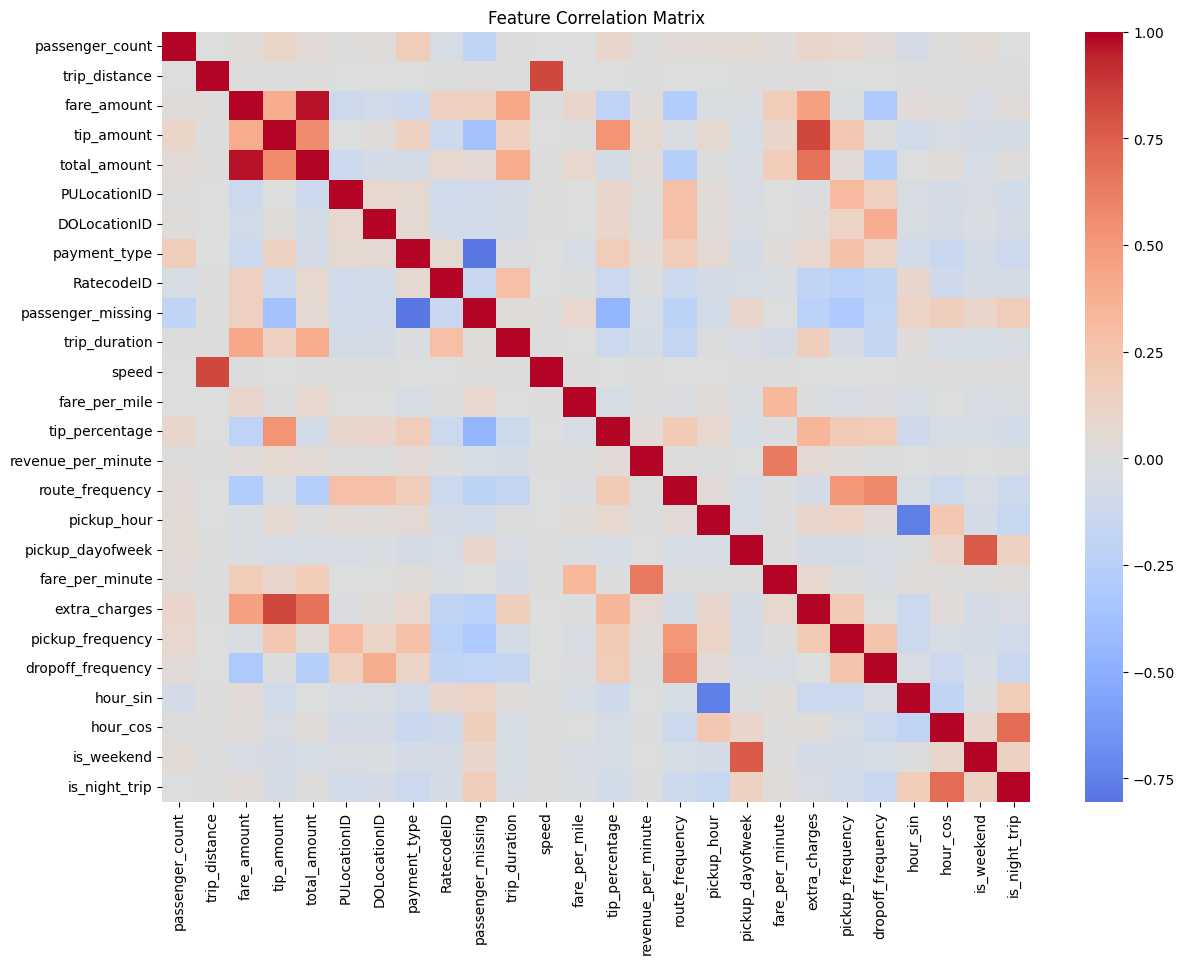

In [44]:
plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")

plt.show()

# Step 13: Remove Intermediate Features

Several columns were used only for feature engineering.

These columns are removed because their information is already captured by engineered features.

Examples:

- pickup_hour → hour_sin, hour_cos
- pickup_dayofweek → is_weekend
- PULocationID → pickup_frequency
- DOLocationID → dropoff_frequency
- route → route_frequency

Removing redundant features helps reduce noise and simplifies model training.

In [48]:
columns_to_drop = [
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "PULocationID",
    "DOLocationID",
    "pickup_hour",
    "pickup_dayofweek",
    "route"
]

existing_cols = [
    col
    for col in columns_to_drop
    if col in df.columns
]

df = df.drop(columns=existing_cols)

print("Remaining Columns:")
print(df.columns.tolist())

Remaining Columns:
['passenger_count', 'trip_distance', 'fare_amount', 'tip_amount', 'total_amount', 'payment_type', 'RatecodeID', 'passenger_missing', 'trip_duration', 'speed', 'fare_per_mile', 'tip_percentage', 'revenue_per_minute', 'route_frequency', 'fare_per_minute', 'extra_charges', 'pickup_frequency', 'dropoff_frequency', 'hour_sin', 'hour_cos', 'is_weekend', 'is_night_trip']


# Step 13: Final Feature Set

Based on business understanding and exploratory analysis, the following features are selected for Isolation Forest training.

These features capture:

- Distance behavior
- Duration behavior
- Speed behavior
- Revenue behavior
- Route behavior
- Temporal behavior

In [49]:
final_features = [

    # Passenger Features
    "passenger_count",
    "passenger_missing",

    # Trip Features
    "trip_distance",
    "trip_duration",
    "speed",

    # Revenue Features
    "fare_amount",
    "tip_amount",
    "total_amount",
    "fare_per_mile",
    "fare_per_minute",
    "tip_percentage",
    "revenue_per_minute",
    "extra_charges",

    # Route Features
    "pickup_frequency",
    "dropoff_frequency",
    "route_frequency",

    # Temporal Features
    "hour_sin",
    "hour_cos",
    "is_weekend",
    "is_night_trip",

    # Operational Features
    "RatecodeID",
    "payment_type"
]

feature_df = df[final_features].copy()

print("Feature Dataset Shape:")
print(feature_df.shape)

feature_df.head()

Feature Dataset Shape:
(3560826, 22)


,passenger_count,passenger_missing,trip_distance,trip_duration,speed,fare_amount,tip_amount,total_amount,fare_per_mile,fare_per_minute,tip_percentage,revenue_per_minute,extra_charges,pickup_frequency,dropoff_frequency,route_frequency,hour_sin,hour_cos,is_weekend,is_night_trip,RatecodeID,payment_type
0,1.0,0,0.97,5.550000,10.486486,7.2,3.66,15.86,7.415036,1.099237,50.826274,2.857143,8.66,94155,77513,8742,0.0,1.0,0,1,1.0,1
1,0.0,0,0.90,5.716667,9.446064,7.9,0.00,13.65,8.768036,1.176179,0.000000,2.387337,5.75,83056,86354,2781,0.0,1.0,0,1,1.0,2
2,0.0,0,1.40,8.883333,9.455910,10.7,2.50,18.95,7.637402,1.082631,23.362303,2.132968,8.25,42010,142364,3083,0.0,1.0,0,1,1.0,1
3,4.0,0,5.58,42.800000,7.822430,38.7,11.11,55.56,6.934241,0.883562,28.707269,1.298101,16.86,106731,9711,81,0.0,1.0,0,1,1.0,1
4,0.0,0,2.16,13.500000,9.600000,13.5,3.85,23.10,6.247108,0.931034,28.516406,1.710984,9.60,11583,34595,232,0.0,1.0,0,1,1.0,1


# Step 15: Validate Feature Dataset

Before training the Isolation Forest model, we verify:

- Missing values
- Infinite values
- Data types

The final dataset must be fully model-ready.

In [50]:
print("Missing Values:")
print(feature_df.isna().sum())

Missing Values:
passenger_count       0
passenger_missing     0
trip_distance         0
trip_duration         0
speed                 0
fare_amount           0
tip_amount            0
total_amount          0
fare_per_mile         0
fare_per_minute       0
tip_percentage        0
revenue_per_minute    0
extra_charges         0
pickup_frequency      0
dropoff_frequency     0
route_frequency       0
hour_sin              0
hour_cos              0
is_weekend            0
is_night_trip         0
RatecodeID            0
payment_type          0
dtype: int64


In [53]:
import numpy as np

print("Infinite Values:")
print(
    np.isinf(
        feature_df.select_dtypes(
            include=np.number
        )
    ).sum()
)

Infinite Values:
passenger_count           0
passenger_missing         0
trip_distance             0
trip_duration             0
speed                 43903
fare_amount               0
tip_amount                0
total_amount              0
fare_per_mile             0
fare_per_minute           0
tip_percentage            0
revenue_per_minute        0
extra_charges             0
pickup_frequency          0
dropoff_frequency         0
route_frequency           0
hour_sin                  0
hour_cos                  0
is_weekend                0
is_night_trip             0
RatecodeID                0
payment_type              0
dtype: int64


In [52]:
feature_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3560826 entries, 0 to 3560825
Data columns (total 22 columns):
 #   Column              Dtype  
---  ------              -----  
 0   passenger_count     float64
 1   passenger_missing   int64  
 2   trip_distance       float64
 3   trip_duration       float64
 4   speed               float64
 5   fare_amount         float64
 6   tip_amount          float64
 7   total_amount        float64
 8   fare_per_mile       float64
 9   fare_per_minute     float64
 10  tip_percentage      float64
 11  revenue_per_minute  float64
 12  extra_charges       float64
 13  pickup_frequency    int64  
 14  dropoff_frequency   int64  
 15  route_frequency     int64  
 16  hour_sin            float64
 17  hour_cos            float64
 18  is_weekend          int64  
 19  is_night_trip       int64  
 20  RatecodeID          float64
 21  payment_type        int64  
dtypes: float64(15), int64(7)
memory usage: 597.7 MB


In [54]:
print("Before:", df.shape)

df = df[df["trip_duration"] > 0]

print("After:", df.shape)

Before: (3560826, 22)
After: (3516922, 22)


In [55]:
df["speed"] = (
    df["trip_distance"]
    /
    (df["trip_duration"] / 60)
)

In [56]:
df.shape

(3516922, 22)

In [58]:
import numpy as np

print("Infinite Values:")
print(
    np.isinf(
        df.select_dtypes(
            include=np.number
        )
    ).sum()
)

Infinite Values:
passenger_count       0
trip_distance         0
fare_amount           0
tip_amount            0
total_amount          0
payment_type          0
RatecodeID            0
passenger_missing     0
trip_duration         0
speed                 0
fare_per_mile         0
tip_percentage        0
revenue_per_minute    0
route_frequency       0
fare_per_minute       0
extra_charges         0
pickup_frequency      0
dropoff_frequency     0
hour_sin              0
hour_cos              0
is_weekend            0
is_night_trip         0
dtype: int64


# Step 14: Save Model-Ready Dataset

The engineered feature dataset is saved for Isolation Forest training in Notebook 3.

In [59]:
feature_df.to_parquet(
    "/home/ed/Desktop/NYC_Taxi_Demand_Forecasting/USECASE5_Anomaly Detection/data/anomaly_features.parquet",
    index=False
)

print("Feature dataset saved successfully.")

Feature dataset saved successfully.
